In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("ev_battery_failure_dataset.csv")

In [38]:
df.isnull().sum()

,0
vehicle_id,0
vehicle_brand,6436
vehicle_model,8204
vehicle_type,6432
manufacturing_year,9829
...,...
thermal_health_score,6329
charging_quality_score,7186
driving_stress_score,6810
predicted_remaining_life_cycles,8974


In [37]:
df.head()

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


In [66]:
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Check again
df.isnull().sum()

,0
manufacturing_year,0
battery_capacity_kwh,0
odometer_km,0
vehicle_age_years,0
cycle_count,0
...,...
fleet_or_private_Private,0
terrain_type_Desert,0
terrain_type_Flat,0
terrain_type_Hilly,0


In [68]:
df.shape

(200000, 157)

In [41]:
df.duplicated().sum()

np.int64(0)

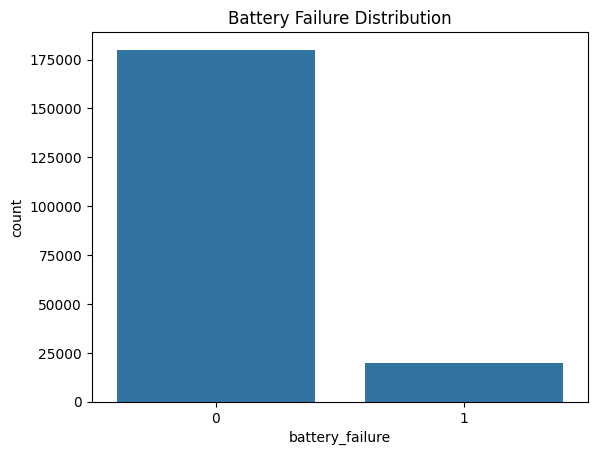

In [67]:
sns.countplot(x='battery_failure', data=df)
plt.title('Battery Failure Distribution')
plt.show()

In [42]:
df.head(

)

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NMC,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,53.5,38.9,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,53.5,100.0,1090.0,0


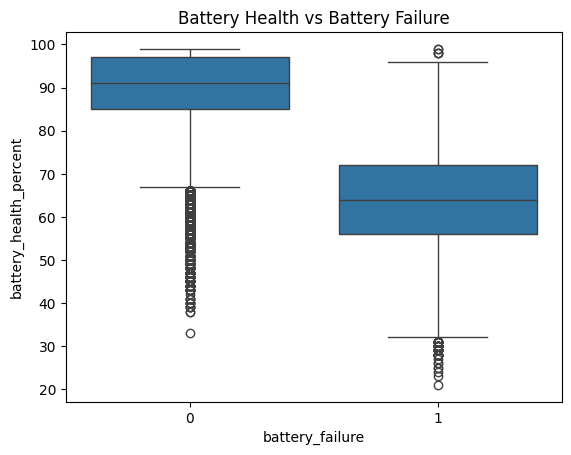

In [69]:
sns.boxplot(x='battery_failure', y='battery_health_percent', data=df)
plt.title('Battery Health vs Battery Failure')
plt.show()

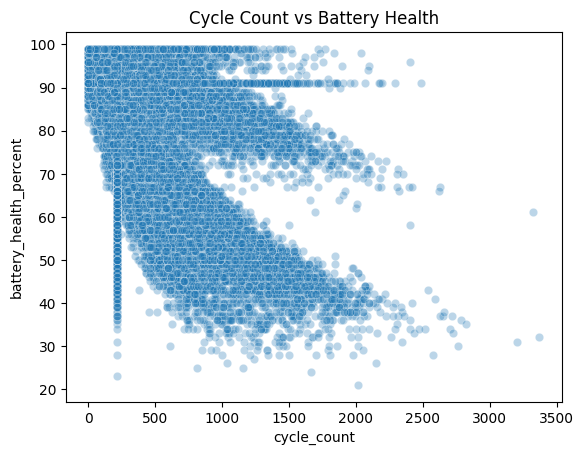

In [70]:
sns.scatterplot(
    x='cycle_count',
    y='battery_health_percent',
    data=df,
    alpha=0.3
)
plt.title('Cycle Count vs Battery Health')
plt.show()

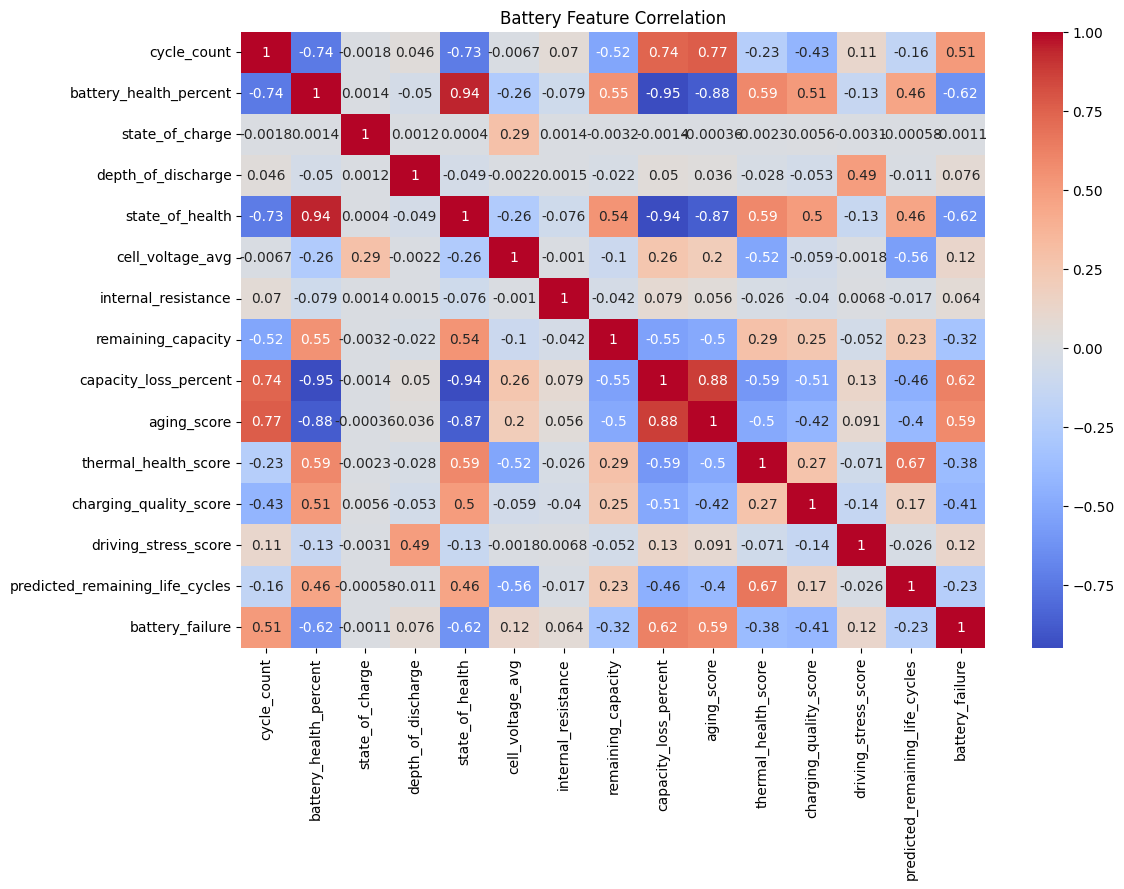

In [71]:
cols = [
    'cycle_count',
    'battery_health_percent',
    'state_of_charge',
    'depth_of_discharge',
    'state_of_health',
    'cell_voltage_avg',
    'internal_resistance',
    'remaining_capacity',
    'capacity_loss_percent',
    'aging_score',
    'thermal_health_score',
    'charging_quality_score',
    'driving_stress_score',
    'predicted_remaining_life_cycles',
    'battery_failure'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Battery Feature Correlation')
plt.show()

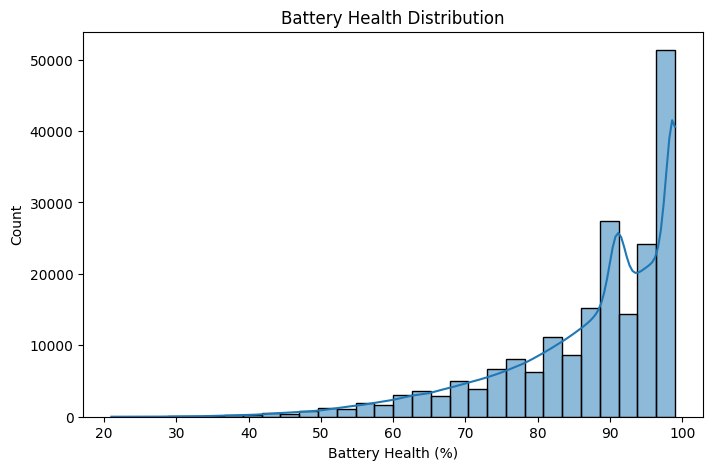

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(df['battery_health_percent'], bins=30, kde=True)
plt.title('Battery Health Distribution')
plt.xlabel('Battery Health (%)')
plt.show()

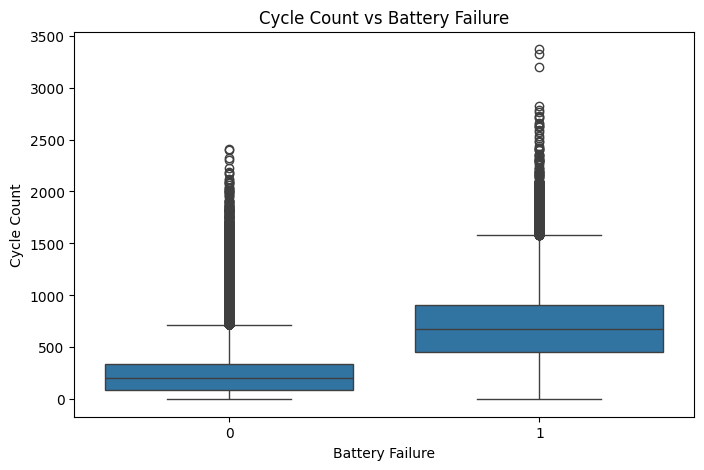

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x='battery_failure', y='cycle_count', data=df)
plt.title('Cycle Count vs Battery Failure')
plt.xlabel('Battery Failure')
plt.ylabel('Cycle Count')
plt.show()

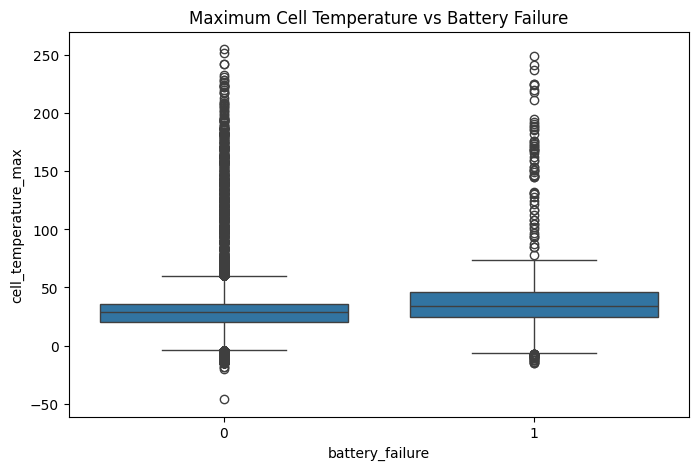

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='battery_failure',
    y='cell_temperature_max',
    data=df
)
plt.title('Maximum Cell Temperature vs Battery Failure')
plt.show()

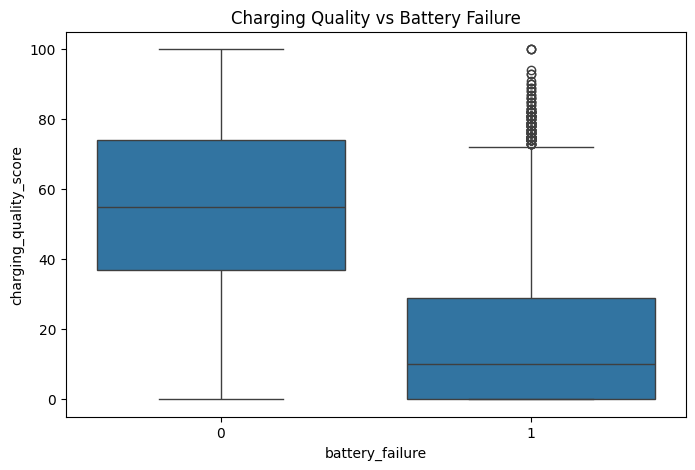

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='battery_failure',
    y='charging_quality_score',
    data=df
)
plt.title('Charging Quality vs Battery Failure')
plt.show()

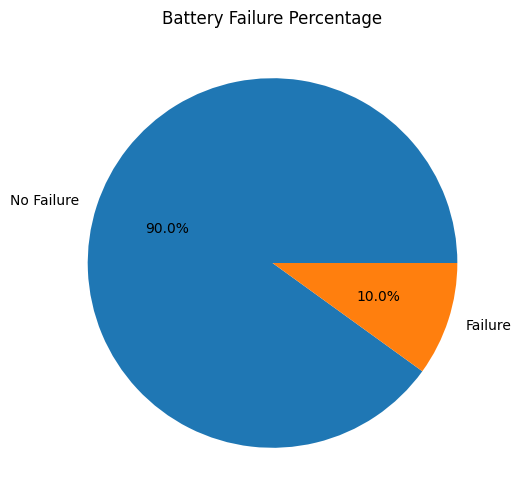

In [76]:
failure_pct = df['battery_failure'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(
    failure_pct,
    labels=['No Failure', 'Failure'],
    autopct='%1.1f%%'
)
plt.title('Battery Failure Percentage')
plt.show()

In [43]:
for col in df.columns:
    print(col)

vehicle_id
vehicle_brand
vehicle_model
vehicle_type
manufacturing_year
battery_manufacturer
battery_chemistry
battery_capacity_kwh
drive_type
odometer_km
vehicle_age_years
fleet_or_private
battery_serial
cycle_count
battery_health_percent
state_of_charge
depth_of_discharge
state_of_health
cell_voltage_avg
cell_voltage_std
pack_voltage
cell_temperature_avg
cell_temperature_max
internal_resistance
charge_efficiency
discharge_efficiency
remaining_capacity
capacity_loss_percent
charging_cycles_last_month
fast_charge_ratio
slow_charge_ratio
average_charge_power_kw
average_charging_time
overnight_charging_ratio
home_charging_ratio
charging_interruptions
overcharge_events
average_speed
average_trip_distance
aggressive_acceleration_score
hard_braking_score
regenerative_braking_usage
highway_driving_ratio
city_driving_ratio
daily_distance
average_ambient_temperature
maximum_temperature
minimum_temperature
humidity
altitude
terrain_type
dust_exposure
last_service_days
cooling_system_health
firmw

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,vehicle_age_years,fleet_or_private,battery_serial,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,cell_voltage_std,pack_voltage,cell_temperature_avg,cell_temperature_max,internal_resistance,charge_efficiency,discharge_efficiency,remaining_capacity,capacity_loss_percent,charging_cycles_last_month,fast_charge_ratio,slow_charge_ratio,average_charge_power_kw,average_charging_time,overnight_charging_ratio,home_charging_ratio,charging_interruptions,overcharge_events,average_speed,average_trip_distance,aggressive_acceleration_score,hard_braking_score,regenerative_braking_usage,highway_driving_ratio,city_driving_ratio,daily_distance,average_ambient_temperature,maximum_temperature,minimum_temperature,humidity,altitude,terrain_type,dust_exposure,last_service_days,cooling_system_health,firmware_updates,previous_faults,maintenance_score,thermal_runaway_risk,voltage_imbalance,temperature_variance,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure,
EV299983,BYD,Song Plus,SUV,2021.0,Samsung SDI,LFP,90.42,AWD,55650.0,4.79,Private,BAT-31543289,322.0,95.94,65.36,34.27,94.74,3.0670,0.01435,766.74,16.60,24.91,0.6127,94.89,93.03,86.75,4.06,1.0,0.295,0.674,33.07,167.9,0.479,0.855,0.0,0.0,52.9,12.9,33.4,56.1,63.8,0.440,0.623,39.3,14.1,19.6,4.6,57.0,342.5,Desert,81.6,251.0,88.1,4.0,1.0,85.9,30.9,19.22,12.13,3.0,3.0,0.0,21.8,7.9,81.5,72.0,51.2,3569.0,0,1
EV299982,Tesla,Model 3,SUV,2020.0,SK On,NCA,91.73,AWD,281442.0,6.34,Fleet,BAT-42912159,599.0,60.61,55.46,24.10,60.05,3.3650,0.03783,841.25,21.71,45.28,0.6821,92.11,90.22,55.59,39.39,8.0,0.509,0.508,51.26,80.9,0.089,0.203,2.0,0.0,64.1,53.2,24.0,4.9,58.7,0.808,0.179,155.6,35.3,39.2,24.0,42.2,602.1,Mountainous,24.1,216.0,58.1,14.0,2.0,100.0,87.5,38.79,9.81,0.0,5.0,0.0,43.2,79.9,37.7,1.1,10.1,361.0,1,1
EV299981,Hyundai,Ioniq 5,Crossover,2020.0,Panasonic,LFP,75.35,RWD,500.0,5.10,Private,BAT-32808882,57.0,99.80,67.13,37.15,98.95,3.0614,0.00569,765.35,3.70,13.20,0.5409,95.07,89.23,66.17,0.20,1.0,0.205,0.777,37.74,89.5,0.243,0.728,0.0,0.0,33.8,1.2,38.2,39.4,33.9,0.286,0.708,3.0,1.3,7.7,-6.1,53.8,41.0,Coastal,31.4,249.0,78.0,3.0,0.0,86.5,13.8,5.87,11.68,1.0,0.0,0.0,24.1,0.0,80.9,77.6,64.3,3928.0,0,1
EV299980,Hyundai,Model X,Sedan,2019.0,CATL,NMC,50.30,RWD,58184.0,7.14,Private,BAT-78403448,263.0,92.27,100.00,20.21,93.76,3.6988,0.01654,849.49,25.39,32.81,0.4216,98.17,93.49,46.41,7.73,4.0,0.034,0.924,11.27,255.6,0.312,0.641,0.0,0.0,43.0,13.1,33.1,24.1,53.9,0.524,0.623,33.1,21.4,30.0,14.1,37.5,270.1,Flat,28.5,129.0,59.6,4.0,2.0,79.8,39.3,17.27,12.04,4.0,0.0,1.0,0.0,24.6,65.6,100.0,25.0,1108.0,0,1
EV299979,Mahindra,BE 6,Sedan,2018.0,CATL,LFP,71.13,AWD,289663.0,7.93,Fleet,BAT-10855374,653.0,85.31,60.94,52.45,85.32,3.0079,0.01993,751.97,9.34,22.99,0.7341,96.29,87.34,60.68,14.69,16.0,0.534,0.438,73.24,69.7,0.194,0.375,0.0,0.0,39.6,54.6,62.6,50.2,65.8,0.554,0.415,122.1,-1.1,2.8,-12.5,59.8,1039.7,Hilly,62.0,432.0,70.4,5.0,2.0,64.9,30.4,24.51,22.16,2.0,2.0,0.0,66.5,37.1,68.6,41.8,86.9,2784.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,11.13,Private,BAT-99314176,287.0,87.40,62.73,65.29,86.17,3.4556,0.02111,863.90,29.71,31.20,0.5663,96.60,93.78,59.47,12.60,5.0,0.250,0.755,44.07,118.2,0.454,0.586,0.0,0.0,61.6,8.1,61.0,35.4,34.2,0.000,1.000,27.5,18.0,29.8,10.3,30.6,283.6,Coastal,3

In [46]:
df.select_dtypes(include=['object']).columns

Index(['vehicle_id', 'vehicle_brand', 'vehicle_model', 'vehicle_type',
       'battery_manufacturer', 'battery_chemistry', 'drive_type',
       'fleet_or_private', 'battery_serial', 'terrain_type'],
      dtype='object')

In [47]:
df.drop(['vehicle_id', 'battery_serial'], axis=1, inplace=True)

In [48]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print(col, df[col].nunique())

vehicle_brand 20
vehicle_model 55
vehicle_type 6
battery_manufacturer 9
battery_chemistry 5
drive_type 3
fleet_or_private 2
terrain_type 5


In [50]:
cat_cols = [
    'vehicle_brand',
    'vehicle_model',
    'vehicle_type',
    'battery_manufacturer',
    'battery_chemistry',
    'drive_type',
    'fleet_or_private',
    'terrain_type'
]

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [51]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [52]:
df = df.astype(int)

In [53]:
df.head()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,battery_chemistry_LTO,battery_chemistry_NCA,battery_chemistry_NMC,drive_type_FWD,drive_type_RWD,fleet_or_private_Private,terrain_type_Desert,terrain_type_Flat,terrain_type_Hilly,terrain_type_Mountainous
0,2019,82,98163,6,250,73,85,26,72,3,...,0,0,0,0,1,1,0,1,0,0
1,2018,64,113600,7,256,85,49,44,86,3,...,0,0,1,0,0,1,0,0,1,0
2,2018,90,242253,7,556,72,54,33,72,3,...,0,0,1,0,1,0,0,1,0,0
3,2022,47,83700,6,353,85,54,37,91,3,...,0,0,1,0,0,1,0,0,1,0
4,2015,68,88784,11,287,87,62,65,86,3,...,0,0,1,1,0,1,0,0,0,0


In [54]:
print(df.columns.tolist())

['manufacturing_year', 'battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'slow_charge_ratio', 'average_charge_power_kw', 'average_charging_time', 'overnight_charging_ratio', 'home_charging_ratio', 'charging_interruptions', 'overcharge_events', 'average_speed', 'average_trip_distance', 'aggressive_acceleration_score', 'hard_braking_score', 'regenerative_braking_usage', 'highway_driving_ratio', 'city_driving_ratio', 'daily_distance', 'average_ambient_temperature', 'maximum_temperature', 'minimum_temperature', 'humidity', 'altitude', 'dust_exposure', 'last_service_days', 'cooling_system_health', 'firmware_updates',

In [55]:
print('battery_failure' in df.columns)

True


In [56]:
from sklearn.model_selection import train_test_split

X = df.drop('battery_failure', axis=1)
y = df['battery_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
model = LogisticRegression()

In [60]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [62]:
y_pred = model.predict(X_test_scaled)

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.96595


In [64]:
print(y.value_counts())

battery_failure
0    180079
1     19921
Name: count, dtype: int64


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     36016
           1       0.85      0.80      0.82      3984

    accuracy                           0.97     40000
   macro avg       0.91      0.89      0.90     40000
weighted avg       0.97      0.97      0.97     40000



In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [83]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [84]:
rf_predict = model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predict))

Random Forest Accuracy: 0.96015


In [87]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, rf_predict))
print(confusion_matrix(y_test, rf_predict))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     36016
           1       0.85      0.73      0.78      3984

    accuracy                           0.96     40000
   macro avg       0.91      0.86      0.88     40000
weighted avg       0.96      0.96      0.96     40000

[[35503   513]
 [ 1081  2903]]


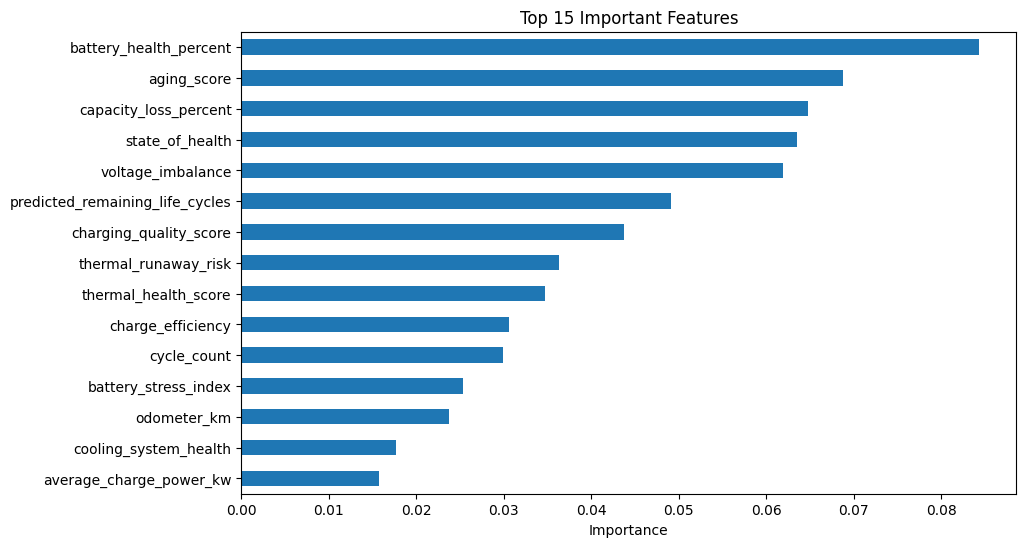

In [88]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
importance.sort_values().plot(kind='barh')

plt.title('Top 15 Important Features')
plt.xlabel('Importance')
plt.show()

In [89]:
import joblib

In [90]:
import joblib

joblib.dump(model, "battery_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']